# SWOT–USGS Station Pairing and Quality Filtering
## Worked example: Willamette River at Albany, OR (USGS 14174000)

This notebook demonstrates how to match USGS stream-gauge stations to SWOT river reaches, filter SWOT water surface elevation (WSE) observations for quality, and compare them to coincident USGS stage records. The Willamette River at Albany is used throughout as a concrete, end-to-end example.

**The notebook covers four parts:**

1. **DFMS.v1 paired station dataset** — 2,960 USGS discharge measurement stations matched to SWORD v17b nodes, filtered to sites observable by SWOT.
2. **SWOT WSE quality filtering** — bit-flag interpretation and vectorised filter functions for SWOT Level 2 RiverSP products.
3. **Pairing a new station** — haversine matching for sites or regions not yet in the pre-built dataset.
4. **Albany worked example** — SWOT WSE time series from Hydrocron, coincident USGS instantaneous gage height from NWIS, datum alignment, pass-level quality breakdown, and ERA5-Land precipitation context.

---
### Data files

| File | Size | Required for | Description |
|---|---|---|---|
| `dfms_v1_us_station_matches.parquet` | 0.2 MB | Parts 1, 4 | 2,960 matched stations — the main lookup table |
| `dfm_v1_us_all_station_matches.parquet` | 4.1 MB | Part 1 | All 73K USGS stations with filter outcomes (for map context) |
| `na_sword_nodes_v17b_pnw.gpkg` | 3.9 MB | Parts 2–3 | SWORD v17b nodes clipped to Pacific Northwest (OR + WA) |
| `figures/dfms_filter_outcomes_*.png` | 3 MB | Part 1 | Pre-generated filter maps (included) |

CSV equivalents (`dfms_v1_us_station_matches.csv`, `dfm_v1_us_all_station_matches.csv`) are provided for users who prefer not to work with Parquet.

> **Note:** The PNW SWORD subset (`na_sword_nodes_v17b_pnw.gpkg`) covers all stations in this notebook. For other regions, download the full NA file from [Zenodo](https://zenodo.org/records/10019999) and update `SWORD_GPKG` in cell 1.

### APIs (no account or download needed)

| API | Used in | Notes |
|---|---|---|
| [Hydrocron](https://podaac.github.io/hydrocron/) | Parts 3–4 | NASA PODAAC — SWOT reach/node time series, public |
| [USGS NWIS IV](https://waterservices.usgs.gov) | Part 4 | Instantaneous gage height, public |
| [Open-Meteo](https://open-meteo.com) | Part 4 | ERA5-Land daily precipitation, public, no key needed |

### Data provenance

**DFMS.v1 station-match table** (`dfms_v1_us_station_matches.parquet`): built from USGS discharge *field measurements* (wading rod, bridge, and boat measurements — not continuous stage records) downloaded from NWIS in January 2026. Stations are matched to SWORD v17b nodes using haversine distance and drainage-area checks.

**USGS instantaneous gage height** (Part 4): fetched live at runtime from `nwis.waterservices.usgs.gov/nwis/iv/` (parameter 00065, feet, 5-minute interval). This is independent of the field-measurement dataset — it is the continuous stage record from the pressure transducer at each gage.

**SWORD version:** v17b — full NA file available from [Zenodo](https://zenodo.org/records/10019999). The PNW subset included here was clipped to the bounding box (−126°, 41°, −120°, 47°).

In [70]:
from pathlib import Path
import math
import requests
from io import StringIO

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import Image, display

DATA_DIR   = Path("/Users/masa6503/repos/swot-precip-validation/data")   # adjust if running from a different directory
SWORD_GPKG = Path("/Users/masa6503/repos/swot-precip-validation/data")   # na_sword_nodes_v17b_pnw.gpkg lives alongside the notebook


---
## Part 1 — The DFMS.v1 paired dataset

### 1.1 Where the stations come from

The map below shows all 70,000+ USGS stream-gauge stations, colour-coded by why they were included or excluded from DFMS.v1.

The dominant rejection reason (**orange/grey**) is **distance**: the nearest SWORD node is too far away, which means the gage is on a tributary or small stream that SWORD doesn't index (SWORD covers rivers large enough for SWOT to observe — roughly ≥ 100 m wide).  
A small number of stations (**purple**) passed the distance test but were rejected because their upstream drainage area differed from the SWORD node's flow accumulation by more than 20% — a sign that the gage and node are on different channels.

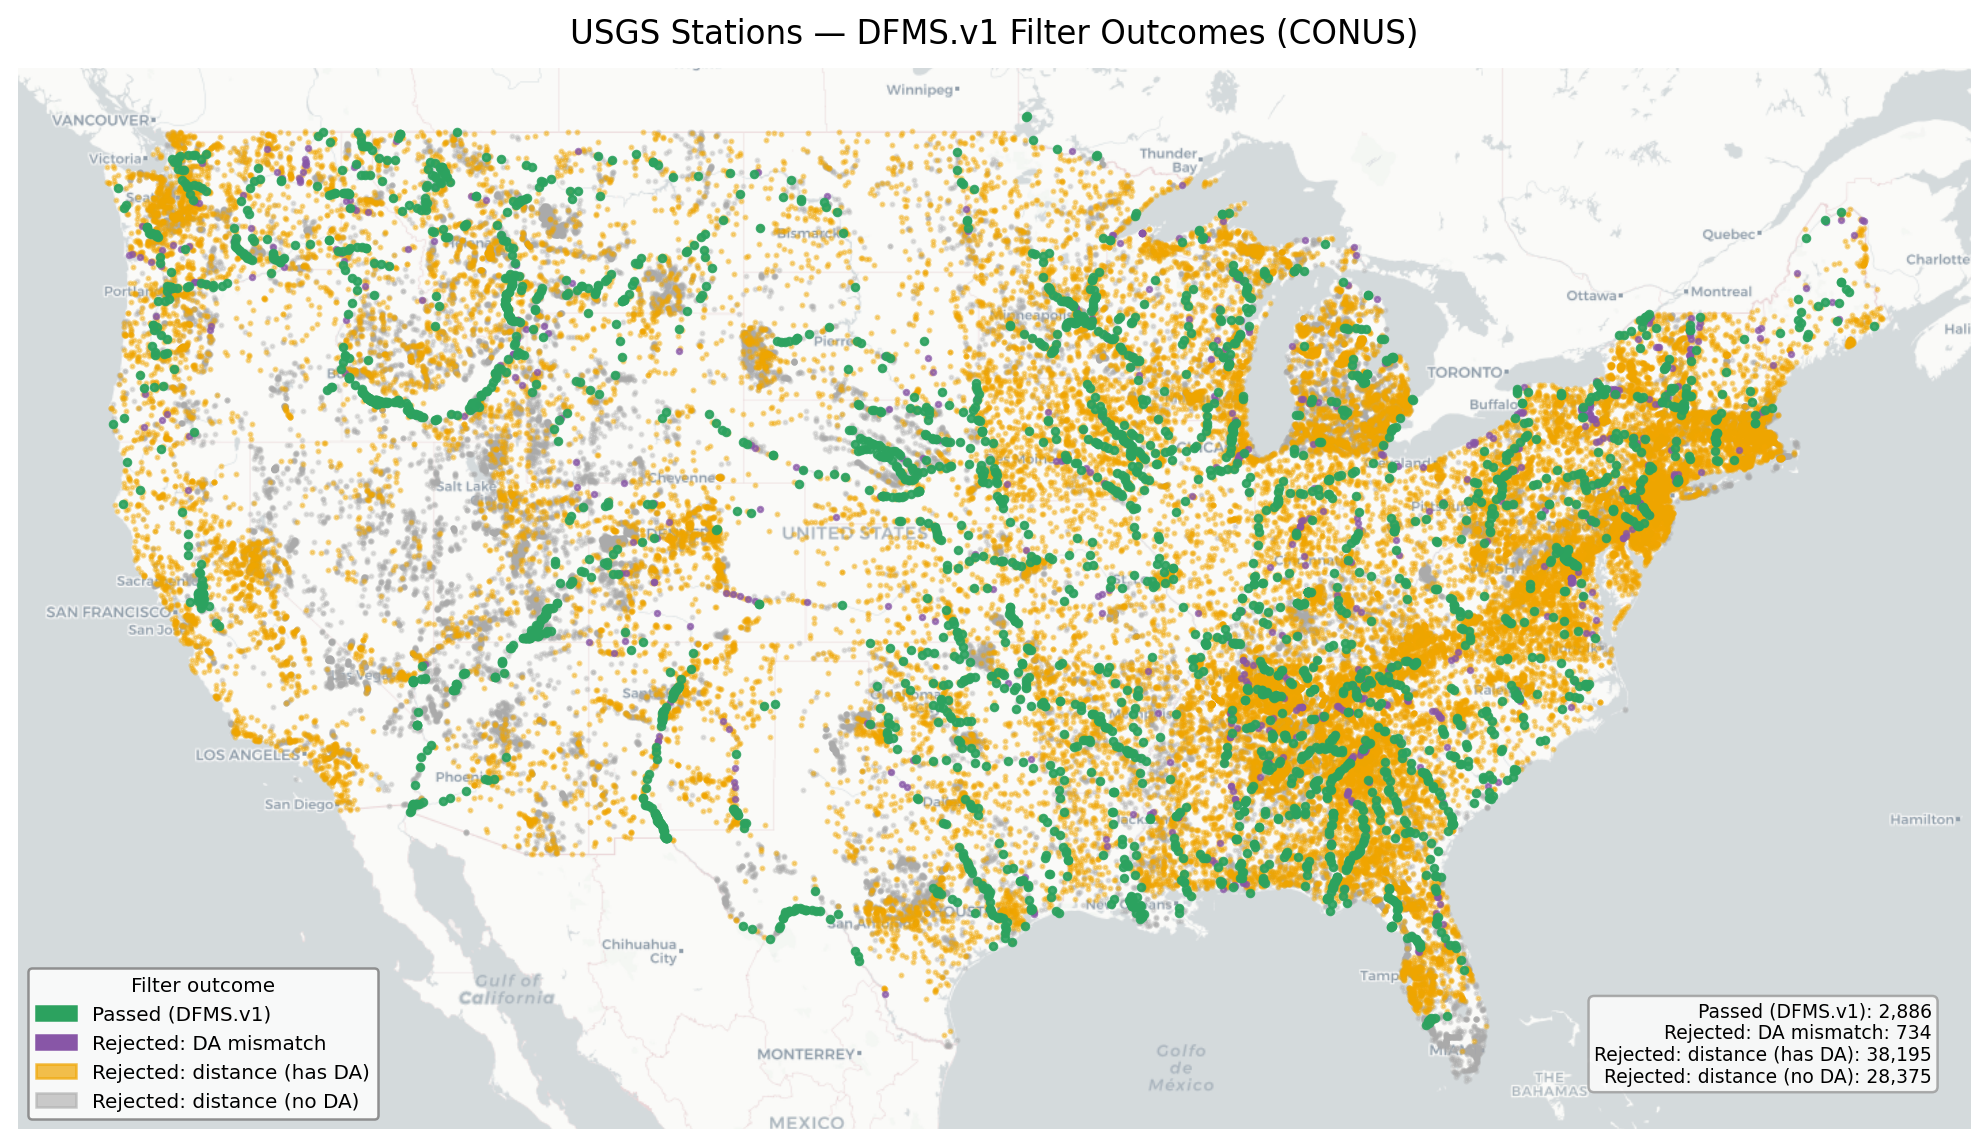

In [71]:
display(Image("/Users/masa6503/repos/swot-precip-validation/figures/dfms_filter_outcomes_conus.png", width=900))

**Filter criteria applied:**
- **Distance filter** (all stations): match distance ≤ 1.5 × SWORD node width. For nodes with unmeasured width, a 500 m cap is used.
- **Drainage area filter** (stations where NWIS reports drainage area): |DA_USGS − DA_SWORD| / DA_USGS ≤ 20%.
  - Stations without NWIS drainage area are evaluated on distance alone.
- **SWOT observability**: the matched SWORD reach must have `swot_obs > 0` (at least one observation per 21-day cycle).

### 1.2 Load the station match table

In [72]:
stations = pd.read_parquet(DATA_DIR / "dfms_v1_us_station_matches.parquet")
print(f"{len(stations):,} stations in DFMS.v1")
stations.head(3)

2,960 stations in DFMS.v1


,usgs_site_no,node_id,reach_id,swot_obs,swot_orbit,match_dist_m,sword_width_m,sword_facc_km2,sword_lakeflag,sword_strm_order,sword_river_name,drain_area_km2,da_ratio,filter_path
0,01010000,72608900080021,72608900081,2,35 242,74.887861,208.5,3469.964836,0,2,Saint John River,3465.40662,0.001315,distance_and_da
1,01010500,72608900010241,72608900011,4,35 242 313 520,43.102647,155.0,6243.206939,0,2,Saint John River,6980.02305,0.105561,distance_and_da
2,01014000,72608700090611,72608700091,1,520,70.008240,127.0,15240.542099,0,3,Saint John River,15356.05071,0.007522,distance_and_da


**Key columns:**
| Column | Description |
|---|---|
| `usgs_site_no` | 8-digit USGS site number |
| `node_id` | Matched SWORD v17b node ID |
| `reach_id` | Parent SWORD v17b reach ID |
| `swot_obs` | SWOT observations per 21-day cycle on this reach |
| `swot_orbit` | Space-separated list of SWOT orbit pass numbers |
| `match_dist_m` | Haversine distance from gage to nearest SWORD node (metres) |
| `sword_width_m` | SWORD prior river width at the matched node (metres) |
| `sword_facc_km2` | SWORD flow accumulation at the node (km², proxy for drainage area) |
| `drain_area_km2` | USGS drainage area from NWIS (km²; NaN if not reported) |
| `da_ratio` | Fractional DA difference: |USGS − SWORD| / USGS (NaN if no USGS DA) |
| `filter_path` | `distance_and_da` or `distance_only` |
| `sword_lakeflag` | 0=river, 1=lake, 2=tidal, 3=canal |
| `sword_river_name` | River name from SWORD ("NODATA" if unnamed) |

In [73]:
# Summary statistics
print("Match distance (m):")
print(stations["match_dist_m"].describe().round(1))
print()
print("Filter path breakdown:")
print(stations["filter_path"].value_counts())
print()
print("SWOT observations per cycle:")
print(stations["swot_obs"].value_counts().sort_index())

Match distance (m):
count     2960.0
mean       424.8
std       2159.2
min          0.6
25%         57.7
50%         88.0
75%        156.8
max      51168.3
Name: match_dist_m, dtype: float64

Filter path breakdown:
filter_path
distance_and_da    1562
distance_only      1398
Name: count, dtype: int64

SWOT observations per cycle:
swot_obs
1     474
2    1398
3     809
4     251
5      26
6       2
Name: count, dtype: int64


### 1.3 Look up a specific station

The Willamette River at Albany (USGS 14174000) is one example Matt mentioned.

In [74]:
site = "14174000"
row = stations[stations["usgs_site_no"] == site]

if len(row) == 0:
    print(f"Station {site} is not in DFMS.v1.")
    print("It may have been filtered out. Check dfm_v1_us_all_station_matches.parquet for its filter outcome.")
else:
    print(row.T)

                              2177
usgs_site_no              14174000
node_id             78220000200081
reach_id               78220000201
swot_obs                         3
swot_orbit              39 274 345
match_dist_m             64.319125
sword_width_m                 77.0
sword_facc_km2        10917.748502
sword_lakeflag                   0
sword_strm_order                 2
sword_river_name  Willamette River
drain_area_km2          12535.5516
da_ratio                  0.129057
filter_path        distance_and_da


In [75]:
# Check the full station match table to see why it was rejected (if it was)
all_matches = pd.read_parquet(DATA_DIR / "dfm_v1_us_all_station_matches.parquet")
result = all_matches[all_matches["usgs_site_no"] == site]
if len(result) > 0:
    print(result[["usgs_site_no","match_dist_m","width","drain_area_km2","facc",
                  "dist_passed","da_result","matched","filter_path","swot_obs"]].T)

                          51942
usgs_site_no           14174000
match_dist_m          64.319125
width                      77.0
drain_area_km2       12535.5516
facc               10917.748502
dist_passed                True
da_result                  True
matched                    True
filter_path     distance_and_da
swot_obs                      3


### 1.4 Regional zoom — densest passing-station cluster

In [76]:
display(Image("figures/dfms_filter_outcomes_regional_zoom.png", width=800))

FileNotFoundError: No such file or directory: 'figures/dfms_filter_outcomes_regional_zoom.png'

FileNotFoundError: No such file or directory: 'figures/dfms_filter_outcomes_regional_zoom.png'

<IPython.core.display.Image object>

The densest cluster of passing stations is in the **Tennessee River basin** (Alabama/Tennessee). This makes sense: the Tennessee and its major tributaries are wide enough for SWOT, heavily gauged, and well-represented in SWORD v17b.

---
## Part 2 — Haversine pairing (how the matching works)

If you need to pair stations not in DFMS.v1, or want to understand how the matching was done, this section walks through the approach from scratch.

### 2.1 Why haversine?

Latitude and longitude are angles on a sphere, not Cartesian coordinates. A 1° longitude step is ~111 km at the equator but only ~55 km at 60°N. Computing Euclidean distance on raw lat/lon values gives wrong answers. The **haversine formula** gives the great-circle distance between two points on a sphere.

In [77]:
def haversine_m(lat1, lon1, lat2, lon2):
    """
    Great-circle distance in metres between (lat1, lon1) and (lat2, lon2).
    Inputs are in decimal degrees. Works on scalars or numpy arrays.
    """
    R = 6_371_000  # Earth mean radius in metres

    # Convert degrees → radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    # Haversine formula
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    return R * 2 * np.arcsin(np.sqrt(a))


# Quick sanity check: New York to Los Angeles ≈ 3,940 km
d = haversine_m(40.71, -74.01, 34.05, -118.24)
print(f"New York → Los Angeles: {d/1000:.0f} km  (expected ≈ 3,940 km)")

New York → Los Angeles: 3935 km  (expected ≈ 3,940 km)


### 2.2 Pair a single station to its nearest SWORD node

We'll use the Albany, OR gage as an example and manually find its nearest SWORD node in the Pacific Northwest.

In [78]:
# ── Station coordinates ───────────────────────────────────────────────────
gage_lat =  44.638733   # Willamette R at Albany, OR (USGS 14174000) — from NWIS
gage_lon = -123.106762

# ── Load SWORD nodes for North America ───────────────────────────────────
# We'll clip to a small bounding box first so the search is fast
nodes = gpd.read_file(
    SWORD_GPKG / "na_sword_nodes_v17b_pnw.gpkg",
    bbox=(-125, 43, -121, 46),   # (min_lon, min_lat, max_lon, max_lat)
    columns=["node_id", "reach_id", "x", "y", "width", "facc", "river_name", "lakeflag"],
)
print(f"Nodes in bounding box: {len(nodes):,}")
nodes.head(3)

Nodes in bounding box: 6,387


,x,y,node_id,reach_id,width,facc,lakeflag,river_name,geometry
0,-123.920533,43.665874,78100600030111,78100600031,231.0,9734.027005,0,Umpqua River,POINT (-123.92053 43.66587)
1,-123.920025,43.664258,78100600030121,78100600031,240.0,9732.387586,0,Umpqua River,POINT (-123.92002 43.66426)
2,-123.918996,43.662645,78100600030131,78100600031,263.0,9730.748168,0,Umpqua River,POINT (-123.919 43.66265)


In [79]:
# Compute haversine distance from the gage to every node in the bounding box
nodes = nodes.copy()
nodes["dist_m"] = haversine_m(
    gage_lat, gage_lon,
    nodes["y"].values,   # node latitude
    nodes["x"].values,   # node longitude
)

# Nearest node
nearest = nodes.loc[nodes["dist_m"].idxmin()]
print("Nearest SWORD node:")
print(f"  node_id:     {nearest['node_id']}")
print(f"  reach_id:    {nearest['reach_id']}")
print(f"  river_name:  {nearest['river_name']}")
print(f"  node lat/lon: {nearest['y']:.4f}, {nearest['x']:.4f}")
print(f"  dist_m:      {nearest['dist_m']:.1f} m")
print(f"  SWORD width: {nearest['width']:.1f} m")
print(f"  SWORD facc:  {nearest['facc']:.0f} km²")

Nearest SWORD node:
  node_id:     78220000200081
  reach_id:    78220000201
  river_name:  Willamette River
  node lat/lon: 44.6389, -123.1060
  dist_m:      64.3 m
  SWORD width: 77.0 m
  SWORD facc:  10918 km²


In [80]:
# Check if the match passes the distance filter  (≤ 1.5 × SWORD width)
FALLBACK_DIST_M = 500
WIDTH_MULTIPLIER = 1.5

width = nearest["width"]
threshold = FALLBACK_DIST_M if width <= 0 else WIDTH_MULTIPLIER * width
dist = nearest["dist_m"]

print(f"Match distance:  {dist:.1f} m")
print(f"Threshold:       {threshold:.1f} m  (1.5 × {width:.1f} m width)")
print(f"Passes distance filter: {dist <= threshold}")

Match distance:  64.3 m
Threshold:       115.5 m  (1.5 × 77.0 m width)
Passes distance filter: True


### 2.3 Scale up: pair many stations at once

For a list of stations, geopandas `sjoin_nearest` efficiently finds the nearest node for each station using an R-tree spatial index — much faster than looping. We then compute exact haversine distances on the matched pairs.

In [81]:
import warnings

# Example: pair a handful of stations
example_stations = pd.DataFrame({
    "site_no":      ["14174000", "14211720", "14306500"],
    "station_name": ["Willamette R at Albany OR", "Willamette R at Portland OR", "Rogue R near Agness OR"],
    "lat":          [44.638733,  45.5175,  42.5679],
    "lon":          [-123.106762, -122.6695, -124.0575],
})

# Build a GeoDataFrame of the stations (geographic CRS)
gdf_stations = gpd.GeoDataFrame(
    example_stations,
    geometry=gpd.points_from_xy(example_stations["lon"], example_stations["lat"]),
    crs="EPSG:4326",
)

# Load SWORD nodes for the region (bounding box around all stations)
bbox = (
    example_stations["lon"].min() - 1,
    example_stations["lat"].min() - 1,
    example_stations["lon"].max() + 1,
    example_stations["lat"].max() + 1,
)
nodes_region = gpd.read_file(
    SWORD_GPKG / "na_sword_nodes_v17b_pnw.gpkg",
    bbox=bbox,
    columns=["node_id", "reach_id", "x", "y", "width", "facc", "river_name", "lakeflag"],
)

# Nearest-neighbour join (geographic CRS — finds correct nearest node)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")  # suppress geographic CRS warning; we compute real distances below
    matched = gpd.sjoin_nearest(
        gdf_stations,
        nodes_region[["node_id", "reach_id", "x", "y", "width", "facc", "river_name", "lakeflag", "geometry"]],
        how="left",
    ).drop(columns=["index_right"])

# Compute true haversine distances on matched pairs
matched["match_dist_m"] = haversine_m(
    matched["lat"].values,
    matched["lon"].values,
    matched["y"].values,   # node lat
    matched["x"].values,   # node lon
)

matched[["site_no", "station_name", "match_dist_m", "width", "facc", "river_name", "node_id", "reach_id"]]

,site_no,station_name,match_dist_m,width,facc,river_name,node_id,reach_id
0,14174000,Willamette R at Albany OR,64.343697,77.0,10917.748502,Willamette River,78220000200081,78220000201
1,14211720,Willamette R at Portland OR,70.251212,284.0,23839.015292,Willamette River,78220000020011,78220000021
2,14306500,Rogue R near Agness OR,325.531048,42.0,10632.768484,Rogue River,78100200060221,78100200061


---
## Part 3 — SWOT quality filtering

SWOT Level 2 RiverSP products include several quality fields. Some are simple integers; others are **bit-packed integers** where each bit represents a different flag. This section shows how to decode them.

### 3.1 Quality fields overview

| Field | Type | Description |
|---|---|---|
| `node_q` / `reach_q` | integer (0–3) | Overall quality: 0=good, 1=suspect, 2=degraded, 3=bad |
| `node_q_b` / `reach_q_b` | bit-packed integer | Individual quality flag bits (see table below) |
| `ice_clm_f` | integer (0/1) | Ice climatology flag — 1 means ice cover likely |
| `xovr_cal_q` | integer (0–2) | Cross-over calibration quality: 0=good, 1=suspect, 2=bad |
| `wse` | float | Water surface elevation (m) — fill value: −999999 |
| `width` | float | River width (m) — fill value: −999999 |

### 3.2 Decoding quality bit flags

The `node_q_b` / `reach_q_b` field is an integer where each bit corresponds to a specific condition. For example, if bit 23 is set, the WSE is flagged as an outlier.

In [82]:
# Map of bit position → flag name
QUALITY_BITS = {
     0: "sig0_qual_suspect",
     1: "classification_qual_suspect",
     2: "geolocation_qual_suspect",
     3: "water_fraction_suspect",
     4: "blocking_width_suspect",
     5: "num_detections_suspect",
     6: "bright_land",
     8: "few_sig0_observations",
    10: "few_area_observations",
    11: "few_wse_observations",
    13: "far_range_suspect",
    14: "near_range_suspect",
    15: "partially_observed",
    18: "classification_qual_degraded",
    19: "geolocation_qual_degraded",
    22: "lake_flagged",
    23: "wse_outlier",
    24: "wse_bad",
    25: "below_min_fit_points",
    26: "no_area_observations",
    27: "no_wse_observations",
    28: "no_pixels",
}


def decode_quality_bits(q_value):
    """
    Decode a SWOT quality bit-packed integer.
    Returns a list of active flag names.

    Example:
        decode_quality_bits(8454144)  # bits 23 and 19 set
        → ['geolocation_qual_degraded', 'wse_outlier']
    """
    if q_value is None or (isinstance(q_value, float) and math.isnan(q_value)):
        return ["MISSING"]
    q_int = int(q_value)
    return [name for bit, name in QUALITY_BITS.items() if q_int & (1 << bit)]


# Example: a value with bits 19 (geolocation degraded) and 23 (wse_outlier) set
example_q_b = (1 << 19) | (1 << 23)   # = 8,913,920
print(f"q_b value: {example_q_b}")
print(f"Active flags: {decode_quality_bits(example_q_b)}")

# Clean observation (no flags set)
print(f"\nClean observation (q_b=0): {decode_quality_bits(0)}")

q_b value: 8912896
Active flags: ['geolocation_qual_degraded', 'wse_outlier']

Clean observation (q_b=0): []


### 3.3 WSE quality filter

The recommended filter for **water surface elevation** follows the SWOT ATBD. A row passes only if *all* of the following are true:

| # | Condition | Field |
|---|---|---|
| 1 | Not ice-covered | `ice_clm_f == 0` |
| 2 | Not flagged as bad | `node_q < 3` or `reach_q < 3` |
| 3 | Cross-over calibration OK | `xovr_cal_q < 2` |
| 4 | WSE is not fill value | `wse ≠ −999999` and not NaN |
| 5 | Not far/near swath edge | bits 13 and 14 not set in `q_b` |
| 6 | Geolocation not degraded | bit 19 not set in `q_b` |
| 7 | WSE not flagged as outlier/bad | bits 23 and 24 not set in `q_b` |

In [83]:
def passes_wse_filter(row):
    """
    Returns (passes: bool, filter_results: dict) for a single SWOT observation.

    Expects columns: ice_clm_f, node_q (or reach_q), xovr_cal_q,
                     wse, node_q_b (or reach_q_b)
    """
    # Pick reach or node quality fields depending on which product you have
    q_field   = "reach_q"   if "reach_q"   in row else "node_q"
    q_b_field = "reach_q_b" if "reach_q_b" in row else "node_q_b"

    active_bits = decode_quality_bits(row.get(q_b_field, 0))

    checks = {
        "ice_free":            row.get("ice_clm_f", 0) == 0,
        "not_bad":             row.get(q_field, 99) < 3,
        "good_xover_cal":      row.get("xovr_cal_q", 99) < 2,
        "wse_not_fill":        pd.notna(row.get("wse")) and row.get("wse") > -9e5,
        "not_swath_edge":      "far_range_suspect"  not in active_bits
                           and "near_range_suspect" not in active_bits,
        "geoloc_ok":           "geolocation_qual_degraded" not in active_bits,
        "wse_not_outlier":     "wse_outlier" not in active_bits
                           and "wse_bad"     not in active_bits,
    }

    return all(checks.values()), checks


# ── Test on a synthetic observation ──────────────────────────────────────
clean_obs = {"ice_clm_f": 0, "reach_q": 0, "xovr_cal_q": 0, "wse": 152.3, "reach_q_b": 0}
bad_obs   = {"ice_clm_f": 0, "reach_q": 0, "xovr_cal_q": 0, "wse": 152.3,
             "reach_q_b": (1 << 23)}  # wse_outlier bit set

ok, detail = passes_wse_filter(clean_obs)
print(f"Clean obs passes: {ok}")

ok, detail = passes_wse_filter(bad_obs)
print(f"WSE-outlier obs passes: {ok}")
print("Filter breakdown:", detail)

Clean obs passes: True
WSE-outlier obs passes: False
Filter breakdown: {'ice_free': True, 'not_bad': True, 'good_xover_cal': True, 'wse_not_fill': True, 'not_swath_edge': True, 'geoloc_ok': True, 'wse_not_outlier': False}


### 3.4 Width / area quality filter

If you are using SWOT **width or area** measurements (rather than WSE), a slightly different filter applies.

In [84]:
def passes_width_filter(row):
    """
    Returns (passes: bool, filter_results: dict) for width/area quality.

    Expects columns: ice_clm_f, node_q (or reach_q), xovr_cal_q,
                     width, node_q_b (or reach_q_b)
    """
    q_field   = "reach_q"   if "reach_q"   in row else "node_q"
    q_b_field = "reach_q_b" if "reach_q_b" in row else "node_q_b"

    active_bits = decode_quality_bits(row.get(q_b_field, 0))

    width = row.get("width", -999999)
    checks = {
        "ice_free":          row.get("ice_clm_f", 0) == 0,
        "not_bad":           row.get(q_field, 99) < 3,
        "good_xover_cal":    row.get("xovr_cal_q", 99) < 2,
        "width_valid":       pd.notna(width) and width != -999999 and width > 0,
        "classif_ok":        "classification_qual_degraded" not in active_bits,
    }

    return all(checks.values()), checks

### 3.5 Apply filters to a DataFrame of SWOT observations

Below is a vectorised approach — faster than `apply()` for large datasets.

In [85]:
def apply_wse_filter_vectorised(df: pd.DataFrame) -> pd.Series:
    """
    Apply the WSE quality filter to a DataFrame of SWOT observations.
    Returns a boolean mask — True means the row passes all filters.

    The q_b column is decoded bit-by-bit using bitwise AND.
    """
    q_col   = "reach_q"   if "reach_q"   in df.columns else "node_q"
    q_b_col = "reach_q_b" if "reach_q_b" in df.columns else "node_q_b"

    q_b = df[q_b_col].fillna(0).astype(int)

    mask = (
        (df.get("ice_clm_f", 0) == 0)                 # not ice
        & (df[q_col] < 3)                              # not bad
        & (df.get("xovr_cal_q", 0) < 2)               # good cross-over
        & (df["wse"].notna()) & (df["wse"] > -9e5)     # WSE not fill
        & (~(q_b & (1 << 13)).astype(bool))            # not far swath
        & (~(q_b & (1 << 14)).astype(bool))            # not near swath
        & (~(q_b & (1 << 19)).astype(bool))            # geoloc OK
        & (~(q_b & (1 << 23)).astype(bool))            # not WSE outlier
        & (~(q_b & (1 << 24)).astype(bool))            # not WSE bad
    )
    return mask

### 3.6 Fetching SWOT data via Hydrocron

To get SWOT time series for a specific reach, use the **Hydrocron API** (NASA PODAAC). You need the `reach_id` from the DFMS.v1 match table. Make sure to request the quality fields needed for filtering.

In [87]:
HYDROCRON_URL = "https://soto.podaac.earthdatacloud.nasa.gov/hydrocron/v1/timeseries"

# Fields confirmed valid in Hydrocron.
# Note: ice_clm_f is in the RiverSP netCDF files but NOT exposed by Hydrocron —
# the ice check in apply_wse_filter_vectorised defaults to "not icy" when the
# column is absent, which is correct for Hydrocron-sourced data.
REACH_FIELDS = (
    "reach_id,pass_id,time_str,reach_q,reach_q_b,xovr_cal_q,"
    "wse,wse_u,slope,width,width_u,area_total,dark_frac,xtrk_dist"
)

NODE_FIELDS = (
    "reach_id,node_id,pass_id,time_str,node_q,node_q_b,xovr_cal_q,"
    "wse,wse_u,width,width_u,area_total,dark_frac,xtrk_dist"
)


def fetch_reach_timeseries(reach_id: int, start: str, end: str) -> pd.DataFrame:
    """
    Fetch SWOT reach time series from Hydrocron (public API — no auth required).

    Parameters
    ----------
    reach_id : int   SWORD reach ID (from dfms_v1_us_station_matches.parquet)
    start    : str   ISO datetime, e.g. '2023-01-01T00:00:00Z'
    end      : str   ISO datetime, e.g. '2024-12-31T23:59:59Z'

    Returns
    -------
    pd.DataFrame of SWOT observations, or empty DataFrame on error.
    """
    params = {
        "feature":    "Reach",
        "feature_id": str(reach_id),
        "start_time": start,
        "end_time":   end,
        "fields":     REACH_FIELDS,
        "output":     "csv",
        "collection_name": "SWOT_L2_HR_RiverSP_D"
    }
    resp = requests.get(HYDROCRON_URL, params=params, timeout=60)
    if resp.status_code != 200:
        print(f"Hydrocron error {resp.status_code}: {resp.text[:300]}")
        return pd.DataFrame()

    # Hydrocron returns JSON-wrapping {"results": {"csv": "..."}} or raw CSV
    try:
        payload = resp.json()
        csv_text = payload["results"]["csv"]
    except Exception:
        csv_text = resp.text  # already plain CSV

    return pd.read_csv(StringIO(csv_text))


print("fetch_reach_timeseries() ready — Hydrocron is a public API, no auth required.")

# ── Usage example — 2-month Albany fetch ─────────────────────────────────
print("\n--- Usage example: Albany reach, Apr–May 2023 ---")
example_df = fetch_reach_timeseries(
    reach_id=78220000201,          # Willamette at Albany (from dfms_v1_us_station_matches)
    start="2023-04-01T00:00:00Z",
    end="2023-05-31T23:59:59Z",
)
for col in ["wse", "reach_q", "reach_q_b", "xovr_cal_q"]:
    if col in example_df.columns:
        example_df[col] = pd.to_numeric(example_df[col], errors="coerce")

example_df["passes_wse_filter"] = apply_wse_filter_vectorised(example_df)
print(f"Observations: {len(example_df)}, passing filter: {example_df['passes_wse_filter'].sum()}")
example_df[["time_str", "wse", "reach_q", "passes_wse_filter"]].head(10)

fetch_reach_timeseries() ready — Hydrocron is a public API, no auth required.

--- Usage example: Albany reach, Apr–May 2023 ---
Observations: 56, passing filter: 54


,time_str,wse,reach_q,passes_wse_filter
0,2023-04-02T08:16:17Z,55.1563,1,True
1,2023-04-03T08:06:55Z,55.3975,1,True
2,2023-04-04T07:57:32Z,55.4243,1,True
3,2023-04-05T07:48:10Z,55.3019,1,True
4,2023-04-06T07:38:48Z,55.2627,1,True
5,2023-04-07T07:29:26Z,55.2934,1,True
6,2023-04-08T07:20:04Z,55.3863,1,True
7,2023-04-09T07:10:43Z,55.6113,1,True
8,2023-04-10T07:01:21Z,55.3006,1,True
9,2023-04-11T06:51:59Z,55.7601,1,True


---
## Quick-reference cheat sheet

```python
# 1. Load paired station table
stations = pd.read_parquet("dfms_v1_us_station_matches.parquet")

# 2. Look up a USGS gage
row = stations[stations["usgs_site_no"] == "14174000"].iloc[0]
reach_id = row["reach_id"]
node_id  = row["node_id"]

# 3. Fetch SWOT time series for that reach
swot = fetch_reach_timeseries(reach_id, "2023-01-01T00:00:00Z", "2024-12-31T23:59:59Z")

# 4. Filter to good WSE observations
good = swot[apply_wse_filter_vectorised(swot)]

# 5. Pair a new station not in DFMS.v1
nodes_local = gpd.read_file("na_sword_nodes_v17b.gpkg", bbox=(lon-1, lat-1, lon+1, lat+1))
nodes_local["dist_m"] = haversine_m(lat, lon, nodes_local["y"], nodes_local["x"])
nearest_node = nodes_local.loc[nodes_local["dist_m"].idxmin()]
```

---
## Part 4 — SWOT WSE vs. USGS gage height with quality filtering

This section fetches the SWOT WSE time series for the Willamette River at Albany reach and compares it against USGS daily mean gage height. Each SWOT observation is colour-coded by its quality filter outcome so you can see which points are usable and why others are rejected.

Hydrocron is a public REST API — no account or credentials needed.

### 4.1 Fetch SWOT WSE and classify filter outcomes

The Hydrocron API returns one row per SWOT pass over the reach. We apply the WSE quality filter from Part 3 and label each point with its primary outcome.

### 4.2 Fetch USGS gage height

In [58]:
def classify_wse_outcome(row) -> str:
    """
    Classify a SWOT reach observation by its WSE quality filter outcome.
    Returns the primary failure reason (or 'Passes filter') as a short label.
    """
    if row["passes_wse"]:
        return "Passes filter"

    q_b = int(row.get("reach_q_b", 0) or 0)
    wse = row.get("wse", None)

    if pd.isna(wse) or wse < -9e5:
        return "Fill value"
    if row.get("reach_q", 0) >= 3:
        return "Bad quality (q≥3)"
    if q_b & (1 << 23) or q_b & (1 << 24):
        return "WSE outlier/bad"
    if q_b & (1 << 13) or q_b & (1 << 14):
        return "Swath edge"
    if q_b & (1 << 19):
        return "Geoloc degraded"
    return "Other flag"


# Fetch SWOT WSE for Willamette at Albany (all passes, 2023 – present)
reach_id_albany = stations[stations["usgs_site_no"] == "14174000"]["reach_id"].iloc[0]
print(f"Fetching SWOT WSE for reach {reach_id_albany} …")

swot_raw = fetch_reach_timeseries(
    reach_id_albany,
    start="2023-01-01T00:00:00Z",
    end="2026-02-28T23:59:59Z",
)

if swot_raw.empty:
    raise RuntimeError(
        f"Hydrocron returned no data for reach {reach_id_albany}. "
        "Check that the reach_id is correct and the Hydrocron service is reachable."
    )

# Parse time as UTC then strip timezone so it stays compatible with USGS IV times
swot_raw["time"] = pd.to_datetime(swot_raw["time_str"], utc=True).dt.tz_convert(None)
for col in ["wse", "reach_q", "reach_q_b", "xovr_cal_q", "ice_clm_f"]:
    if col in swot_raw.columns:
        swot_raw[col] = pd.to_numeric(swot_raw[col], errors="coerce")

# Apply WSE filter and classify outcomes
swot_raw["passes_wse"] = apply_wse_filter_vectorised(swot_raw)
swot_raw["outcome"]    = swot_raw.apply(classify_wse_outcome, axis=1)

print(f"\nTotal SWOT passes:        {len(swot_raw)}")
print(f"Passing WSE filter:       {swot_raw['passes_wse'].sum()}")
print(f"\nOutcome breakdown:")
print(swot_raw["outcome"].value_counts().to_string())

Fetching SWOT WSE for reach 78220000201 …

Total SWOT passes:        206
Passing WSE filter:       158

Outcome breakdown:
outcome
Passes filter      158
Swath edge          37
Geoloc degraded     11


### 4.3 Datum alignment

**SWOT WSE** is referenced to the **EGM2008 geoid** (via SWORD). **USGS gage height** is in feet above an arbitrary local datum (site-specific; check the NWIS site page). These two reference frames cannot be overlaid without a datum offset.

We fetch **USGS instantaneous values (IV)** for the same date window as the SWOT data, then use `merge_asof` to pair each SWOT pass with the nearest USGS IV reading within ±2 hours — truly coincident measurements. The datum offset is then:

```
datum_offset_m  =  median( SWOT_WSE  −  USGS_gage_height_m )
                   over quality-passing coincident pairs
```

For plotting, the IV record is resampled to hourly means to keep the figure responsive.

In [59]:
def fetch_usgs_gage_height_iv(site_no: str, start: str, end: str) -> pd.DataFrame:
    """
    Fetch USGS instantaneous gage height (parameter 00065, ft) from NWIS.
    Returns raw 5-minute readings with columns: time (tz-naive UTC), gage_height_m.
    """
    params = {
        "format":      "json",
        "sites":       site_no,
        "startDT":     start,
        "endDT":       end,
        "parameterCd": "00065"
    }
    resp = requests.get(
        "https://nwis.waterservices.usgs.gov/nwis/iv/",
        params=params, timeout=120,
    )
    resp.raise_for_status()

    ts_list = resp.json()["value"]["timeSeries"]
    if not ts_list:
        return pd.DataFrame(columns=["time", "gage_height_m"])

    records = ts_list[0]["values"][0]["value"]
    df = pd.DataFrame(records)
    # dateTime comes back with local offset; convert to UTC and drop tzinfo
    df["time"] = pd.to_datetime(df["dateTime"], utc=True).dt.tz_convert(None)
    df["gage_height_m"] = pd.to_numeric(df["value"], errors="coerce") * 0.3048
    return df[["time", "gage_height_m"]].dropna().reset_index(drop=True)


# ── Fetch USGS IV only for the date span covered by SWOT passes ──────────
swot_start = swot_raw["time"].min().strftime("%Y-%m-%d")
swot_end   = swot_raw["time"].max().strftime("%Y-%m-%d")
print(f"SWOT pass window: {swot_start} → {swot_end}  ({len(swot_raw)} passes)")
print("Fetching USGS IV gage height for that window …")

usgs_iv = fetch_usgs_gage_height_iv("14174000", swot_start, swot_end)
print(f"USGS IV records: {len(usgs_iv):,}")

# ── Coincident matching: nearest USGS IV reading to each SWOT pass ────────
# merge_asof finds the closest-in-time USGS reading for every SWOT row;
# tolerance=2 h rejects pairs where the gap is too large (e.g. data gaps).
swot_for_merge = swot_raw[["time", "wse", "passes_wse", "outcome"]].sort_values("time")
usgs_sorted    = usgs_iv.sort_values("time")

coincident = pd.merge_asof(
    swot_for_merge,
    usgs_sorted,
    on="time",
    direction="nearest",
    tolerance=pd.Timedelta("15 minutes"),
)
n_matched = coincident["gage_height_m"].notna().sum()
print(f"SWOT passes with coincident USGS IV reading (±2 h): {n_matched}/{len(swot_raw)}")

# ── Datum offset from quality-passing coincident pairs ────────────────────
good = coincident[coincident["passes_wse"] & coincident["gage_height_m"].notna()]
n_paired = len(good)

if n_paired >= 3:
    datum_offset_m = (good["wse"] - good["gage_height_m"]).median()
    print(f"\nQuality-passing coincident pairs: {n_paired}")
    print(f"Median datum offset (SWOT − USGS IV): {datum_offset_m:.3f} m")
    print("  → USGS gage height shifted by this amount to align with SWOT EGM2008 reference.")
else:
    datum_offset_m = 0.0
    print(f"Too few coincident pairs ({n_paired}); datum offset set to 0.")

# Resample IV to hourly for the continuous plot line (avoids plotting 300K points)
usgs_plot = (
    usgs_iv.set_index("time")["gage_height_m"]
    .resample("1h").mean()
    .reset_index()
    .rename(columns={"gage_height_m": "gage_height_m"})
)

SWOT pass window: 2023-03-29 → 2026-02-26  (206 passes)
Fetching USGS IV gage height for that window …
USGS IV records: 299,311
SWOT passes with coincident USGS IV reading (±2 h): 206/206

Quality-passing coincident pairs: 158
Median datum offset (SWOT − USGS IV): 52.467 m
  → USGS gage height shifted by this amount to align with SWOT EGM2008 reference.


In [67]:
swot_raw.columns

Index(['reach_id', 'pass_id', 'time_str', 'reach_q', 'reach_q_b', 'xovr_cal_q',
       'wse', 'wse_u', 'slope', 'width', 'width_u', 'area_total', 'dark_frac',
       'xtrk_dist', 'wse_units', 'wse_u_units', 'slope_units', 'width_units',
       'width_u_units', 'area_total_units', 'dark_frac_units',
       'xtrk_dist_units', 'time', 'passes_wse', 'outcome'],
      dtype='object')

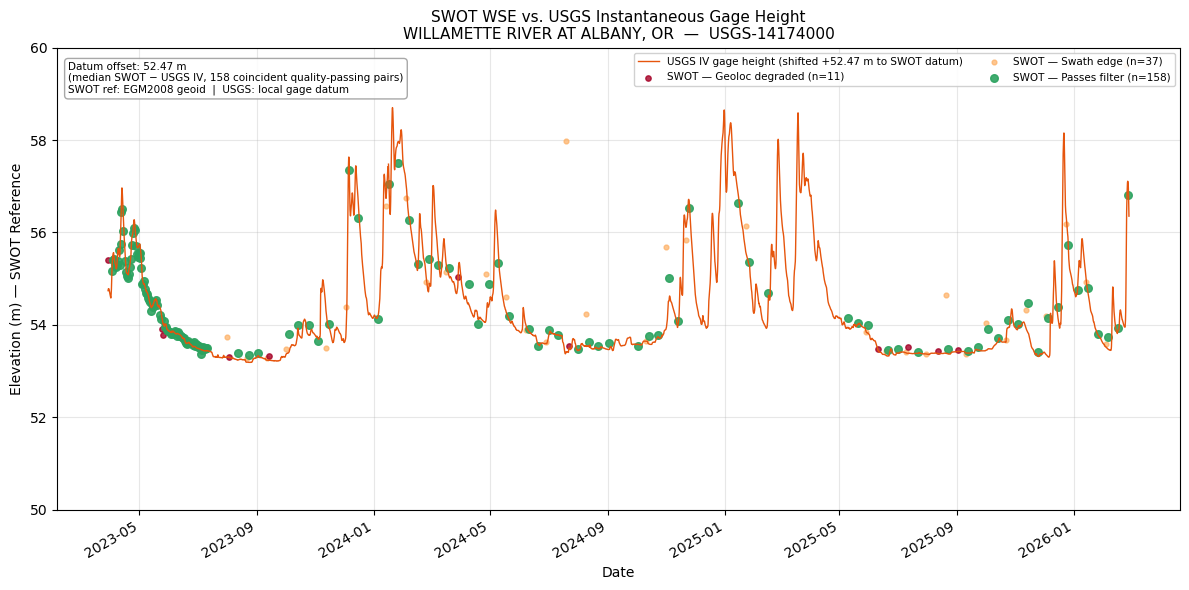

In [63]:
OUTCOME_STYLE = {
    "Passes filter":     {"color": "#2ca25f", "zorder": 5, "s": 30,  "alpha": 0.9},
    "Fill value":        {"color": "#aaaaaa", "zorder": 1, "s": 12,  "alpha": 0.5},
    "Bad quality (q≥3)": {"color": "#d73027", "zorder": 3, "s": 18,  "alpha": 0.8},
    "WSE outlier/bad":   {"color": "#f46d43", "zorder": 4, "s": 18,  "alpha": 0.8},
    "Swath edge":        {"color": "#fdae61", "zorder": 2, "s": 12,  "alpha": 0.7},
    "Geoloc degraded":   {"color": "#a50026", "zorder": 3, "s": 15,  "alpha": 0.8},
    "Other flag":        {"color": "#9ecae1", "zorder": 2, "s": 12,  "alpha": 0.6},
}

fig, ax = plt.subplots(figsize=(12, 6))

# USGS IV gage height (hourly, shifted to SWOT datum)
ax.plot(
    usgs_plot["time"],
    usgs_plot["gage_height_m"] + datum_offset_m,
    color="#e6550d", lw=1.0, zorder=6,
    label=f"USGS IV gage height (shifted +{datum_offset_m:.2f} m to SWOT datum)",
)

# SWOT scatter — fill values have no meaningful WSE position, skip them
swot_scatter = swot_raw[swot_raw["wse"] > -9e5]
for label, style in reversed(list(OUTCOME_STYLE.items())):
    subset = swot_scatter[swot_scatter["outcome"] == label]
    if len(subset) == 0:
        continue
    ax.scatter(
        subset["time"], subset["wse"],
        color=style["color"], s=style["s"], zorder=style["zorder"],
        alpha=style["alpha"], label=f"SWOT — {label} (n={len(subset)})",
    )

# Datum offset annotation
ax.annotate(
    f"Datum offset: {datum_offset_m:.2f} m\n"
    f"(median SWOT − USGS IV, {n_paired} coincident quality-passing pairs)\n"
    "SWOT ref: EGM2008 geoid  |  USGS: local gage datum",
    xy=(0.01, 0.97), xycoords="axes fraction",
    va="top", ha="left", fontsize=7.5,
    bbox=dict(boxstyle="round,pad=0.35", fc="white", alpha=0.85, ec="0.6"),
)

ax.set_xlabel("Date")
ax.set_ylabel("Elevation (m) — SWOT Reference")
ax.set_title(
    "SWOT WSE vs. USGS Instantaneous Gage Height\n"
    "WILLAMETTE RIVER AT ALBANY, OR  —  USGS-14174000",
    fontsize=11,
)
ax.legend(loc="upper right", fontsize=7.5, framealpha=0.9, ncol=2)
ax.grid(True, alpha=0.3)
ax.set_ylim(50,60)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [65]:
subset.columns

Index(['reach_id', 'pass_id', 'time_str', 'reach_q', 'reach_q_b', 'xovr_cal_q',
       'wse', 'wse_u', 'slope', 'width', 'width_u', 'area_total', 'dark_frac',
       'xtrk_dist', 'wse_units', 'wse_u_units', 'slope_units', 'width_units',
       'width_u_units', 'area_total_units', 'dark_frac_units',
       'xtrk_dist_units', 'time', 'passes_wse', 'outcome'],
      dtype='object')

---
### 4.4 Pass-level quality breakdown and WSE uncertainty

SWOT observes each reach from multiple orbit passes per cycle, each at a different cross-track distance from nadir. The panels below show how quality varies by pass number, the WSE uncertainty range for each outcome category, and which subsidiary quality flags tend to co-occur with `geolocation_qual_degraded`.

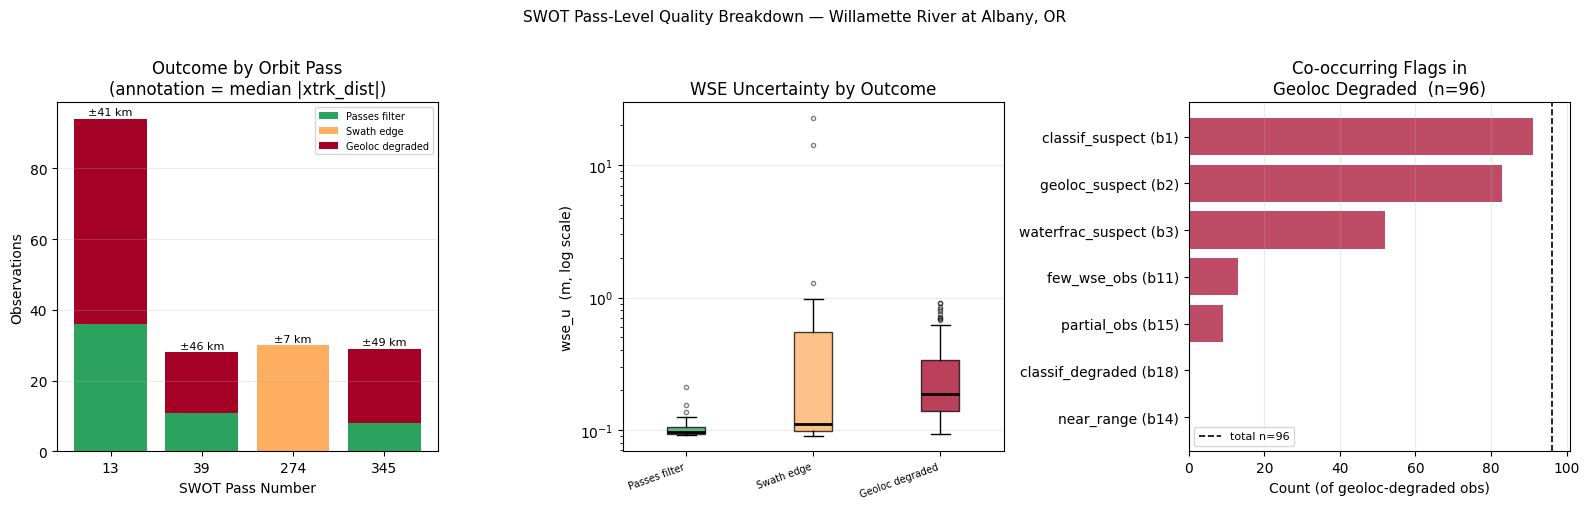

In [21]:
# ── Ensure numeric types for diagnostic columns ──────────────────────────
for col in ["wse_u", "xtrk_dist", "pass_id"]:
    if col in swot_raw.columns:
        swot_raw[col] = pd.to_numeric(swot_raw[col], errors="coerce")

sv = swot_raw[swot_raw["wse"] > -9e5].copy()
sv["pass_id"] = sv["pass_id"].fillna(-1).astype(int)
sv["xtrk_km"] = sv["xtrk_dist"].abs() / 1000

pass_ids     = sorted(sv["pass_id"].unique())
outcome_order = [k for k in OUTCOME_STYLE if k in sv["outcome"].values]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Panel 1: stacked outcome bar per pass ────────────────────────────────
ax = axes[0]
pivot = (sv.groupby(["pass_id", "outcome"])
           .size().unstack(fill_value=0)
           .reindex(columns=outcome_order, fill_value=0))

bottoms  = np.zeros(len(pass_ids))
xlabels  = [str(p) for p in pass_ids]
for outcome in outcome_order:
    vals = np.array([pivot.loc[p, outcome] if p in pivot.index else 0
                     for p in pass_ids], dtype=float)
    ax.bar(xlabels, vals, bottom=bottoms,
           color=OUTCOME_STYLE[outcome]["color"], label=outcome)
    bottoms += vals

for i, pid in enumerate(pass_ids):
    med_km = sv.loc[sv["pass_id"] == pid, "xtrk_km"].median()
    ax.text(i, bottoms[i] + 0.5, f"\u00b1{med_km:.0f} km",
            ha="center", va="bottom", fontsize=8)

ax.set_xlabel("SWOT Pass Number")
ax.set_ylabel("Observations")
ax.set_title("Outcome by Orbit Pass\n(annotation = median |xtrk_dist|)")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.25, axis="y")

# ── Panel 2: wse_u distribution by outcome (log scale) ───────────────────
ax = axes[1]
wse_u_groups = [(o, sv.loc[sv["outcome"] == o, "wse_u"].dropna().values)
                for o in outcome_order
                if sv.loc[sv["outcome"] == o, "wse_u"].dropna().size > 0]

bp = ax.boxplot(
    [d for _, d in wse_u_groups], patch_artist=True, showfliers=True,
    flierprops={"marker": "o", "markersize": 3, "alpha": 0.5},
    medianprops={"color": "black", "lw": 2},
)
for patch, (outcome, _) in zip(bp["boxes"], wse_u_groups):
    patch.set_facecolor(OUTCOME_STYLE[outcome]["color"])
    patch.set_alpha(0.75)

ax.set_xticks(range(1, len(wse_u_groups) + 1))
ax.set_xticklabels([o for o, _ in wse_u_groups], fontsize=7,
                   rotation=20, ha="right")
ax.set_yscale("log")
ax.set_ylabel("wse_u  (m, log scale)")
ax.set_title("WSE Uncertainty by Outcome")
ax.grid(True, alpha=0.25, axis="y")

# ── Panel 3: co-occurring flags in geoloc-degraded obs ───────────────────
ax = axes[2]
geo_qb = sv.loc[sv["outcome"] == "Geoloc degraded", "reach_q_b"].fillna(0).astype(int)
n_geo  = len(geo_qb)

co_bits = {
    "classif_suspect (b1)":  1,
    "geoloc_suspect (b2)":   2,
    "waterfrac_suspect (b3)": 3,
    "few_wse_obs (b11)":     11,
    "near_range (b14)":      14,
    "partial_obs (b15)":     15,
    "classif_degraded (b18)": 18,
}
counts = {name: int((geo_qb & (1 << bit)).astype(bool).sum())
          for name, bit in co_bits.items()}
counts = dict(sorted(counts.items(), key=lambda x: x[1]))   # ascending for barh

ax.barh(list(counts.keys()), list(counts.values()), color="#a50026", alpha=0.7)
ax.axvline(n_geo, color="black", lw=1.2, ls="--", label=f"total n={n_geo}")
ax.set_xlabel("Count (of geoloc-degraded obs)")
ax.set_title(f"Co-occurring Flags in\nGeoloc Degraded  (n={n_geo})")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25, axis="x")

plt.suptitle(
    "SWOT Pass-Level Quality Breakdown — Willamette River at Albany, OR",
    y=1.01, fontsize=11,
)
plt.tight_layout()
plt.show()


### 4.5 Precipitation context

Daily precipitation from [Open-Meteo](https://open-meteo.com) ERA5-Land reanalysis (~10 km grid, no account required) for the Albany, OR grid cell. Grey ticks mark each SWOT overpass time.

Fetching precipitation 2023-03-29 → 2025-04-29 …


Days: 763  |  Rainy days (>1 mm): 278
Max daily precip: 55.9 mm
Source: Open-Meteo ERA5-Land reanalysis, 0.1 deg grid, daily total precip


/tmp/ipykernel_4036982/4155156642.py:74: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.autofmt_xdate()


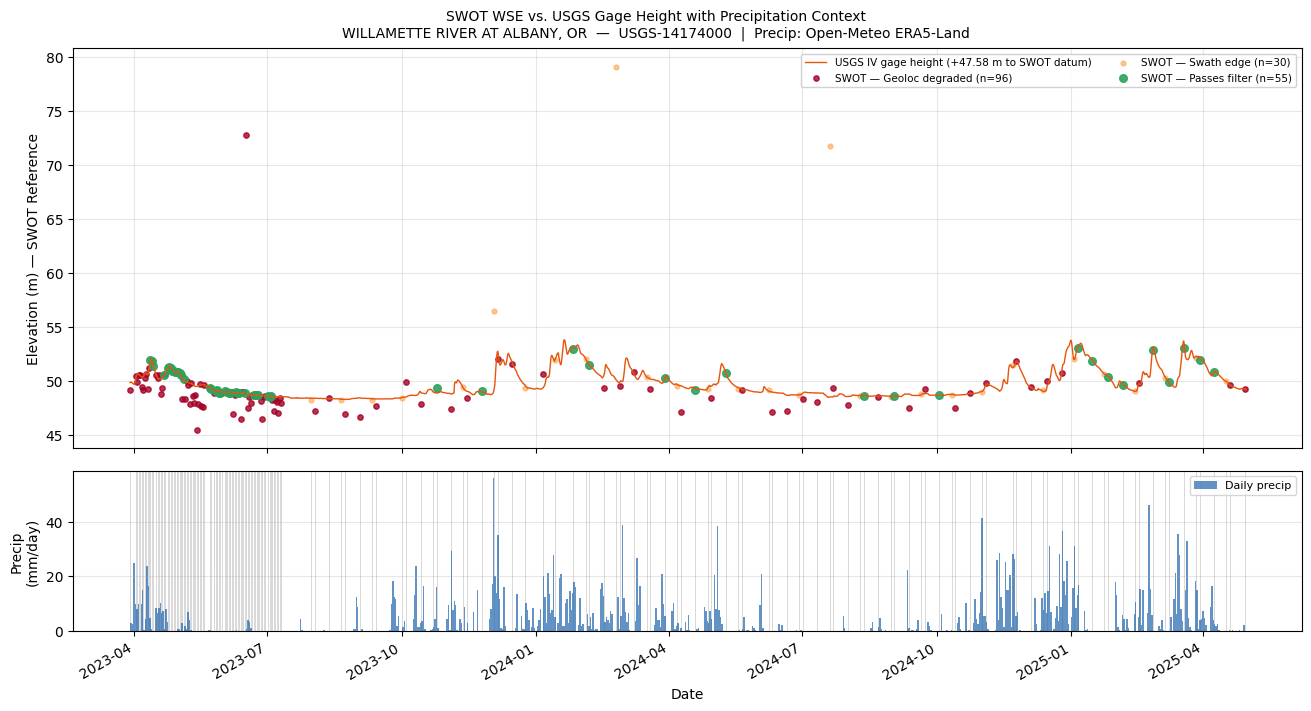

In [22]:
# ── Fetch daily precipitation — Open-Meteo ERA5-Land, no auth needed ─────
print(f"Fetching precipitation {swot_start} → {swot_end} …")
pr_resp = requests.get(
    "https://archive-api.open-meteo.com/v1/archive",
    params={
        "latitude":   44.638,
        "longitude": -123.107,
        "start_date": swot_start,
        "end_date":   swot_end,
        "daily":      "precipitation_sum",
        "timezone":   "UTC",
    },
    timeout=60,
)
pr_resp.raise_for_status()

pr_raw = pr_resp.json()["daily"]
precip = pd.DataFrame({
    "time":      pd.to_datetime(pr_raw["time"]),
    "precip_mm": pd.to_numeric(pd.Series(pr_raw["precipitation_sum"]), errors="coerce").fillna(0),
})
print(f"Days: {len(precip)}  |  Rainy days (>1 mm): {(precip['precip_mm'] > 1).sum()}")
print(f"Max daily precip: {precip['precip_mm'].max():.1f} mm")
print("Source: Open-Meteo ERA5-Land reanalysis, 0.1 deg grid, daily total precip")

# ── 2-panel figure: SWOT+USGS on top, precipitation on bottom ────────────
fig, (ax_wse, ax_pr) = plt.subplots(
    2, 1, figsize=(13, 7), sharex=True,
    gridspec_kw={"height_ratios": [2.5, 1], "hspace": 0.05},
    layout="constrained",
)

# — Top: SWOT WSE scatter + USGS IV line (mirrors Part 4 figure) ─────────
ax_wse.plot(
    usgs_plot["time"], usgs_plot["gage_height_m"] + datum_offset_m,
    color="#e6550d", lw=1.0, zorder=6,
    label=f"USGS IV gage height (+{datum_offset_m:.2f} m to SWOT datum)",
)
swot_sc = swot_raw[swot_raw["wse"] > -9e5]
for label, style in reversed(list(OUTCOME_STYLE.items())):
    sub = swot_sc[swot_sc["outcome"] == label]
    if not len(sub):
        continue
    ax_wse.scatter(
        sub["time"], sub["wse"],
        color=style["color"], s=style["s"],
        zorder=style["zorder"], alpha=style["alpha"],
        label=f"SWOT — {label} (n={len(sub)})",
    )
ax_wse.set_ylabel("Elevation (m) — SWOT Reference")
ax_wse.legend(loc="upper right", fontsize=7.5, ncol=2, framealpha=0.9)
ax_wse.grid(True, alpha=0.3)
ax_wse.tick_params(axis="x", labelbottom=False)

# — Bottom: daily precipitation bars, SWOT pass ticks ────────────────────
ax_pr.bar(
    precip["time"], precip["precip_mm"],
    width=pd.Timedelta(days=1), color="#2166ac", alpha=0.7, label="Daily precip",
)
for t in swot_raw["time"]:
    ax_pr.axvline(t, color="#555555", lw=0.4, alpha=0.4, zorder=0)

ax_pr.set_ylabel("Precip\n(mm/day)")
ax_pr.set_xlabel("Date")
ax_pr.legend(fontsize=8, loc="upper right")
ax_pr.grid(True, alpha=0.3, axis="y")

fig.suptitle(
    "SWOT WSE vs. USGS Gage Height with Precipitation Context\n"
    "WILLAMETTE RIVER AT ALBANY, OR  —  USGS-14174000  "
    "|  Precip: Open-Meteo ERA5-Land",
    fontsize=10,
)
fig.autofmt_xdate()
plt.show()
